# Validation Duck

## Paths & Co

In [1]:
new_initial_state = False
new_kalman_run = True
animation = False

In [2]:
# paths jupyter utwente
path_tc = '/home/jovyan/data/98_paper2_kf_dtm/01_tides/output/'
path_validation = '/home/jovyan/data/98_paper2_kf_dtm/02_Duck_validation_data/'

path_input_general = '/home/jovyan/data/98_paper2_kf_dtm/0_input_general/'
path_input = '/home/jovyan/data/98_paper2_kf_dtm/22_23_Duck_DEM/input/'
path_output = '/home/jovyan/data/98_paper2_kf_dtm/22_23_Duck_DEM/output/'
path_altimetry_output = '/home/jovyan/data/98_paper2_kf_dtm/21_Duck_altimetry/output/'

# filenames for gebco and DeltaDTM
fn_gebco = 'gebco_2024_n36.6257_s35.7784_w-76.1201_e-75.3896.nc'
fn_ddtm = 'DeltaDTM_v1_0_N36W076.tif'

epsg = 4326 # WGS84
epsg_local = 32618

year_start = 1993
year_end = 2020 # included

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Imports

In [3]:
%load_ext autoreload
%autoreload 2

import pdb

import os
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import xarray as xr
import time
import itertools

from scipy import stats

from shapely import LineString
from shapely.ops import split

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import colormaps as cm
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

from coastal_data import CD_statistics, CD_combine_data, \
    CD_geometry, CD_kalman, CD_jarkus_tools, CD_visualisation

/home/jovyan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
# matplotlib fontsizes
SMALL_SIZE = 15
MEDIUM_SIZE = 20
BIGGER_SIZE = 25
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)   # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)   # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

## Parameters

In [5]:
# Observational noise
beach_slope = 0.015 # tan beta
rmse_h_cassie = 20 # [m]
std_alt = 0.1 # [m]
rms_eot20 = 0.1  # [m]
sigma_l = np.sqrt((beach_slope * rmse_h_cassie)**2 + std_alt**2 + rms_eot20**2)

print(f'Observational noise: {round(sigma_l,2)} m')

# Model noise
factor = 10
sigma_q = factor * sigma_l
print(f'Model noise: {round(sigma_q,2)} m')

# Standard deviation of the initial state
std_init = 1
print(f'Standard deviation of the initial state: {round(std_init,2)} m')

Observational noise: 0.33 m
Model noise: 3.32 m
Standard deviation of the initial state: 1 m


In [6]:
# Define T as identity matrix or with spatial dependencies
T_is_identity = True # Use identity matrix
# T_is_identity = False # Model spatial dependencies

# T-matrix with spatial dependencies
# if not T_is_identity:
# All points within `max_distance` around the point of iterest (identitcal point)
# are considered neighbouring points
max_distance = 150

# Weight of the identical point in T
# (residual weight is equally distributed between neighbouring points)
w_id = 0.5

# Number of iterations where a grid point does not get updated in a row
# before infusing a pseudo observation from the initial state
max_noupdate = 5

# Standard deviation of pseudo-observations
std_pseudobs = 1 # [m]

# eps: parameter in function 'sparsify matrix'
# smallest absolute value allowed in a sparse matrix
# eps = mean(diag) / eps_factor
# only important if using T with spatial averaging
eps_factor = 1e9

## Observations

In [7]:
# Altimetry
fn = 'tp_plus_ales_epsg32618.csv'
alt = pd.read_csv(path_altimetry_output+fn, index_col='time', parse_dates=['time'])

In [8]:
# Tidal correction
fn = 'tides_duck.csv'
tidal_corr = pd.read_csv(path_tc+fn, index_col='dates', parse_dates=['dates'])

In [9]:
# Cassie shorelines
folders = ['1_1992-08-10_1995-02-24/',
          '2_1995-03-21_2001-03-12/',
          '3_2001-04-13_2009-03-18/',
          '4_2009-04-12_2018-02-07/',
          '5_2018-02-23_2025-03-06/']
sl_cassie = CD_combine_data.combine_cassie(path_input+'1_shorelines_cassie/', folders, epsg=epsg)

# Reduce shorelines to the altimetry period
idx, = np.where((np.array(sl_cassie['dates']) >= alt.index[0]) & (np.array(sl_cassie['dates']) <= alt.index[-1]))

c_dates = np.array(sl_cassie['dates'], dtype=object)[idx]
c_shorelines = np.array(sl_cassie['shorelines'], dtype=object)[idx]

# number of points per shoreline
n_sl_points = np.array([len(_) for _ in c_shorelines])
print(f"{len(c_shorelines)} Landsat/Cassie shorelines in total in the altimetry period. "
    f"Shorelines have on average {int(np.nanmean(n_sl_points))} points (min: {np.nanmin(n_sl_points)}, max: {np.nanmax(n_sl_points)}).")

292 Landsat/Cassie shorelines in total in the altimetry period. Shorelines have on average 90 points (min: 55, max: 215).


## Validation data

In [10]:
duck_vali = xr.open_dataset(path_validation+'duck_validation.nc')

# Reduce to time after 1992
vali_years = pd.to_datetime(duck_vali.time).year
idx_time, = np.where((vali_years >= year_start) & (vali_years <= year_end))
duck_vali = duck_vali.isel(time=idx_time)

In [11]:
# xarray DataSet to GeoDataFrame
lon_vali = duck_vali.longitude.values.reshape(-1)
lat_vali = duck_vali.latitude.values.reshape(-1)

elev_vali = duck_vali['elevation'].values.reshape(len(duck_vali.time), len(duck_vali.xFRF)*len(duck_vali.yFRF))

dates = pd.to_datetime(duck_vali.time)
vali_df = pd.DataFrame(elev_vali, index=dates)

# yearly means anchored in June
# https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
valid_df_yearly = vali_df.groupby(pd.Grouper(freq='YE-JUN')).mean()
valid_df_yearly.index = valid_df_yearly.index.year

vali_gdf = gpd.GeoDataFrame(valid_df_yearly.T, geometry=gpd.points_from_xy(lon_vali, lat_vali))
vali_gdf = vali_gdf.set_crs('4326')
vali_gdf.columns = [str(_) for _ in vali_gdf.columns]

In [12]:
# Outer boundary for initial state
vali_bound = vali_gdf.geometry.union_all().convex_hull

## Initial state

In [13]:
resolution_m = 50 # [m], resolution of the target grid in x- and y-direction
fn_init = f'init_{epsg}_resolution_{resolution_m}m.tif'
if (not os.path.isfile(path_output + fn_init)) | new_initial_state:
    buffer_size = 500 # [m], buffer radius of target area around the set of shorelines
    if epsg == 4326:
        buffer_size = CD_geometry.dist_meter_to_dist_deg(buffer_size) # [deg]
        resolution_deg = CD_geometry.dist_meter_to_dist_deg(resolution_m) # [deg]

    smooth_factor = 10 # Smoothing of shorelines used to compute the median shoreline

    # Target area
    # alpha (how much slack around the concave hull)
    if epsg == 4326:
        alpha = 100
    elif epsg == 28992:
        alpha = 3e-4    

    # Buffer around median shoreline
    med_sl = CD_geometry.median_shoreline_from_transect_intersections(c_shorelines, spacing=100,
                                                                      transect_length=5000, smooth_factor=smooth_factor)
    poly_target = med_sl.buffer(buffer_size)
    # Polgon around the shorelines
    poly_shorelines = CD_geometry.get_area_covered_by_shorelines(c_shorelines, alpha=alpha, buffer_size=0)

    pickle.dump(med_sl, open(path_output + f'med_sl{epsg}.pkl', 'wb'))
    pickle.dump(poly_target, open(path_output + f'poly_target{epsg}.pkl', 'wb'))

    CD_kalman.initial_state(poly_target, med_sl, epsg, resolution_deg, c_shorelines, alt,
                            path_input+'2_global_DEMs/', path_output, fn_init, fn_gebco, fn_ddtm)
else:
    med_sl = pickle.load(open(path_output + f'med_sl{epsg}.pkl', 'rb')) 
    poly_target = pickle.load(open(path_output + f'poly_target{epsg}.pkl', 'rb')) 
    poly_shorelines = pickle.load(open(path_output + f'poly_sl_{epsg}.pkl', 'rb'))
poly_target_red = pickle.load(open(path_output + f'poly_target_red_{epsg}.pkl', 'rb')) 

Always load `init`, even if it was computed in this go (otherwise there is one case where init is a dataframe, and one case where it is an xarray DataSet):

In [14]:
init = xr.open_dataset(path_output+fn_init).squeeze()

fn_poly_sl = f'poly_sl_{epsg}.pkl'
poly_sl = pickle.load(open(path_output + fn_poly_sl, 'rb'))

fn_target_poly = f'poly_target{epsg}.pkl'
poly_target = pickle.load(open(path_output + fn_target_poly, 'rb'))

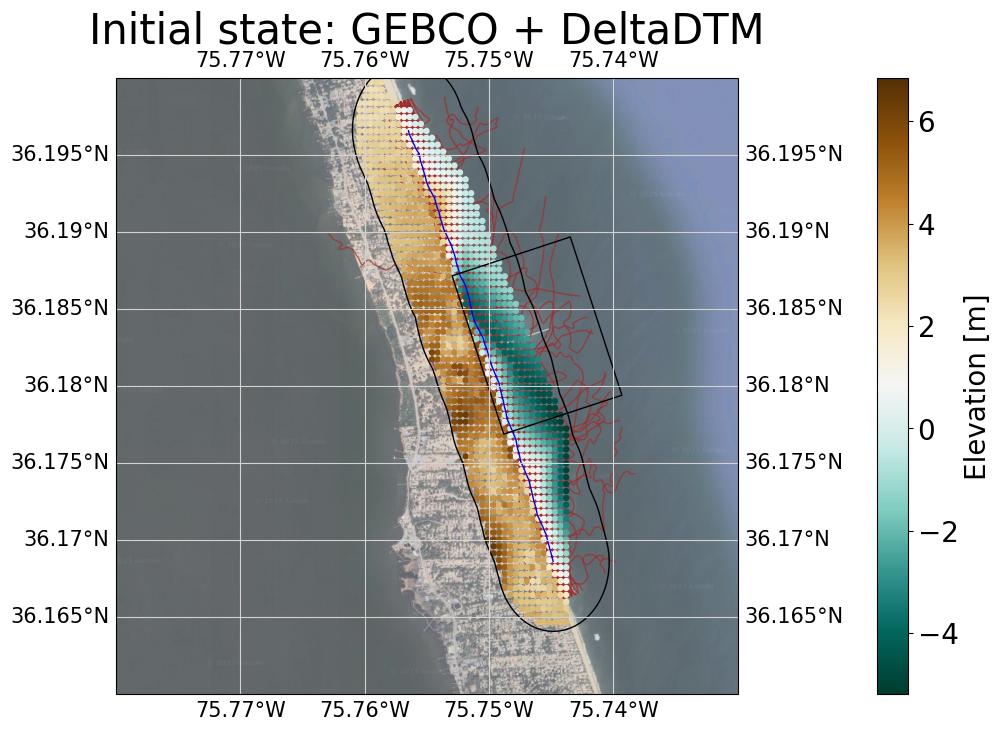

In [15]:
# Plot intial state
init_df = init.to_dataframe()
x = init_df.index.get_level_values('x')
y = init_df.index.get_level_values('y')

projection = ccrs.PlateCarree()
# extent = [-75.76, -75.735, 36.175, 36.19] # zoom in
extent = [-75.78, -75.73, 36.16, 36.2]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

for sl in c_shorelines:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='brown', zorder=1, alpha=.7)
    
ax.add_geometries(poly_target, crs=projection, facecolor='none', edgecolor='black')
ax.add_geometries(med_sl, crs=projection, facecolor='none', edgecolor='blue')
ax.add_geometries(vali_bound, crs=projection, facecolor='none', edgecolor='black')
    
plot = ax.scatter(x, y, c=init_df.band_data, transform=projection, marker='.', s=50,
                  cmap='BrBG_r') #, vmin=-10, vmax=10)
fig.colorbar(plot, shrink=1, pad=0.12, label='Elevation [m]')
ax.set_title('Initial state: GEBCO + DeltaDTM', fontsize=30);

# plt.savefig(f'{path_partun}initial_state.png', dpi=300, bbox_inches='tight')

## Shoreline outlier rejection

In [16]:
# shoreline outlier rejection
init_df = init.to_dataframe().reset_index().dropna()
zcontour = CD_geometry.get_DEM_contour(init_df['x'], init_df['y'], init_df['band_data'], h=0, tarea=poly_target)

t_factor = 1 # threshold = t_factor * mean, (mean of distances to reference shoreline), points inside that range are kept
c_shorelines_corr = CD_geometry.shoreline_outlier_rejection(c_shorelines, zcontour, epsg, t_factor)

poly_sl_corr = CD_geometry.get_area_covered_by_shorelines(c_shorelines_corr, alpha=100, buffer_size=0)

35.0% of shoreline points were discarded.


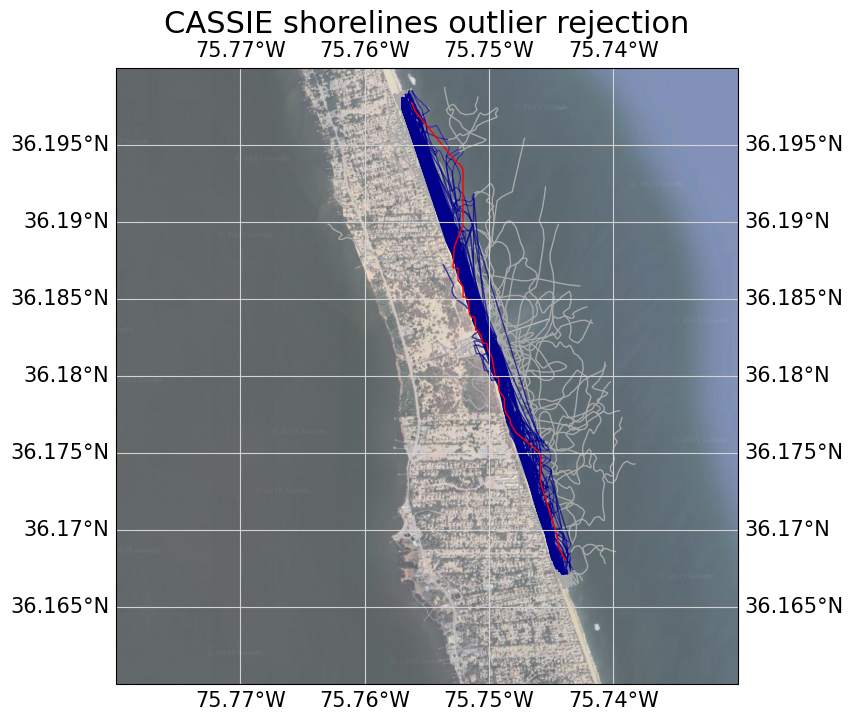

In [17]:
extent = [-75.78, -75.73, 36.16, 36.2]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)
ax.set_title('CASSIE shorelines outlier rejection', fontsize=22);

for sl in c_shorelines:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='darkgrey', zorder=1, alpha=1)
for sl in c_shorelines_corr:
    ax.add_geometries(LineString(sl), crs=projection, facecolor='none', edgecolor='darkblue', zorder=1, alpha=.7)
    
ax.add_geometries(zcontour, crs=projection, facecolor='none', edgecolor='red', zorder=1, alpha=1)

# proxy_before = Line2D([0], [0], color='darkgrey', label='Shorelines before outlier rejection')
# proxy_after = Line2D([0], [0], color='darkblue', label='Shorelines after outlier rejection')
# proxy_zcontour = Line2D([0], [0], color='red', label='Zero contour')
# ax.legend(handles=[proxy_before, proxy_after, proxy_zcontour])

# plt.savefig(f'{path_output}shoreline_outlier_rejection.png', dpi=300, bbox_inches='tight')

## Generate RTS-DTM

In [18]:
# %%prun -s cumulative
fn = 'x_state_s.pkl'
if (not os.path.isfile(path_output + fn)) | new_kalman_run:
    rs_shoreline = {"dates":c_dates, "shorelines":c_shorelines_corr}
    seg_length = 50 # [m] # segment length used for equalise line string
    seg_length = CD_geometry.dist_meter_to_dist_deg(seg_length) # [deg]
    
    x_state, sigma_xx_up, sigma_xx_pred, updated_points, T = CD_kalman.forward_run(year_start, year_end, init, std_init, rs_shoreline, seg_length, alt, tidal_corr,
                                                                                          epsg, T_is_identity, max_distance, w_id, max_noupdate, std_pseudobs,
                                                                                          sigma_l, sigma_q, eps_factor)
            
    x_state_s, sigma_xx_s = CD_kalman.backward_run(x_state, sigma_xx_up, sigma_xx_pred, year_end, T, eps_factor)
        
    kf_interp, rts_interp = CD_kalman.interpolate_results(vali_gdf, x_state, x_state_s, updated_points)

    # Save kf output
    pickle.dump(x_state, open(f'{path_output}x_state.pkl', 'wb'))
    pickle.dump(sigma_xx_up, open(f'{path_output}sigma_xx_up.pkl', 'wb'))
    pickle.dump(sigma_xx_pred, open(f'{path_output}sigma_xx_pred.pkl', 'wb'))
    pickle.dump(updated_points, open(f'{path_output}updated_points.pkl', 'wb'))
    
    # Save RTS output
    pickle.dump(x_state_s, open(f'{path_output}x_state_s.pkl', 'wb'))
    pickle.dump(sigma_xx_s, open(f'{path_output}sigma_xx_s.pkl', 'wb'))

    # Save interpolated outputs
    pickle.dump(kf_interp, open(f'{path_output}kf_interp.pkl', 'wb'))
    pickle.dump(rts_interp, open(f'{path_output}rts_interp.pkl', 'wb'))
else:
    # Load KF output
    x_state = pickle.load(open(f'{path_output}x_state.pkl', 'rb'))
    sigma_xx_up = pickle.load(open(f'{path_output}sigma_xx_up.pkl', 'rb'))
    sigma_xx_pred = pickle.load(open(f'{path_output}sigma_xx_pred.pkl', 'rb'))
    updated_points = pickle.load(open(f'{path_output}updated_points.pkl', 'rb'))

    # Load RTS output
    x_state_s = pickle.load(open(f'{path_output}x_state_s.pkl', 'rb'))
    sigma_xx_s = pickle.load(open(f'{path_output}sigma_xx_s.pkl', 'rb'))

    # Load interpolated outputs
    kf_interp = pickle.load(open(f'{path_output}kf_interp.pkl', 'rb'))
    rts_interp = pickle.load(open(f'{path_output}rts_interp.pkl', 'rb'))
    
    print(f"Loaded files from {path_output}.")
    

Forward run done. Needed  6.5 seconds.
Backward run done. Needed  1.1 seconds.
Interpolation done. Needed  2.1 seconds.


## Statistics of elevation differences

In [19]:
vali_gdf = vali_gdf.drop(columns=['2012', '2021'], errors='ignore')

In [20]:
init_interp = gpd.GeoDataFrame(
        {'geometry':gpd.points_from_xy(vali_gdf.geometry.x, vali_gdf.geometry.y)}).set_crs('4326')
init_interp['init'] = CD_jarkus_tools.interpolate_irregular_grid_onto_JARKUS(x_state, 'init', vali_gdf.geometry.x, vali_gdf.geometry.y)

In [21]:
# Reduce to area inside the shoreline polygon
init_inside_sl = init_interp[init_interp.intersects(poly_sl_corr)]
vali_inside_sl = vali_gdf[vali_gdf.intersects(poly_sl_corr)]
kf_inside_sl = kf_interp[kf_interp.intersects(poly_sl_corr)]
rts_inside_sl = rts_interp[rts_interp.intersects(poly_sl_corr)]

### Initial state - validation

In [22]:
vali_temp_mean = vali_gdf.drop(columns='geometry').T.mean()

diff_init = init_interp['init'] - vali_temp_mean
print(f'Difference initial state - vali has {len(diff_init.dropna())} non-NaN values.')

Difference initial state - vali has 1653 non-NaN values.


In [23]:
CD_statistics.print_stats(diff_init)

Mean error: -0.04 m
---De-bias with mean---
Mean error: -0.0 m
Mean absolute error: 1.11 m
Root mean square error: 1.56 m
Mean absolute deviation from mean: 1.11 m
Median absolute deviation from median: 0.63 m


In [24]:
year_list = [int(_) for _ in vali_inside_sl.drop(columns='geometry').columns]
stats_gdf_init, all_diffs_init = CD_statistics.all_stats_per_year(init_interp['init'], vali_gdf, year_list, reduce_mean=True, static=True)

# Consider only points inside shoreline polygon
stats_gdf_init_in_sl, all_diffs_init_in_sl = CD_statistics.all_stats_per_year(init_inside_sl['init'], vali_inside_sl, year_list, reduce_mean=True, static=True)

### RTS/KF-DTM - validation

In [25]:
year_list = [int(_) for _ in rts_interp.drop(columns='geometry').columns]
stats_gdf_rts, all_diffs_rts = CD_statistics.all_stats_per_year(rts_interp, vali_gdf, year_list, reduce_mean=True, static=False)
stats_gdf_kf, all_diffs_kf = CD_statistics.all_stats_per_year(kf_interp, vali_gdf, year_list, reduce_mean=True, static=False)

# Consider only points inside shoreline polygon
stats_gdf_rts_in_sl, all_diffs_rts_in_sl = CD_statistics.all_stats_per_year(rts_inside_sl, vali_inside_sl, year_list, reduce_mean=True, static=False)
stats_gdf_kf_in_sl, all_diffs_kf_in_sl = CD_statistics.all_stats_per_year(kf_inside_sl, vali_inside_sl, year_list, reduce_mean=True, static=False)

In [26]:
c_init = 'grey'
c_kf = 'brown'
c_rts = 'orange'

In [27]:
def plot_stats(ax, which_stat, title, legend=False, inside_sl=False):
    if inside_sl==False:
        ax.plot(stats_gdf_init.index.astype('int'), stats_gdf_init[which_stat], '.-', c=c_init, label='Initial state - validation')
        ax.plot(stats_gdf_kf.index.astype('int'), stats_gdf_kf[which_stat], '.-', c=c_kf, label='KF-DTM - validation')
        ax.plot(stats_gdf_rts.index.astype('int'), stats_gdf_rts[which_stat], '.-', c=c_rts, label='RTS-DTM - validation')
    
    elif inside_sl==True:
        ax.plot(stats_gdf_init_in_sl.index.astype('int'), stats_gdf_init_in_sl[which_stat], '.-', c=c_init, label='Initial state - validation')
        ax.plot(stats_gdf_kf_in_sl.index.astype('int'), stats_gdf_kf_in_sl[which_stat], '.-', c=c_kf, label='KF-DTM - validation')
        ax.plot(stats_gdf_rts_in_sl.index.astype('int'), stats_gdf_rts_in_sl[which_stat], '.-', c=c_rts, label='RTS-DTM - validation')
    
    ax.grid()
    if legend:
        ax.legend(bbox_to_anchor=(1,1), fontsize=25)
    ax.set_xlabel('Year')
    ax.set_ylabel('[m]')
    ax.set_title(title, fontsize=23, y=1)
    # ax.ticklabel_format(useOffset=False, style='plain')

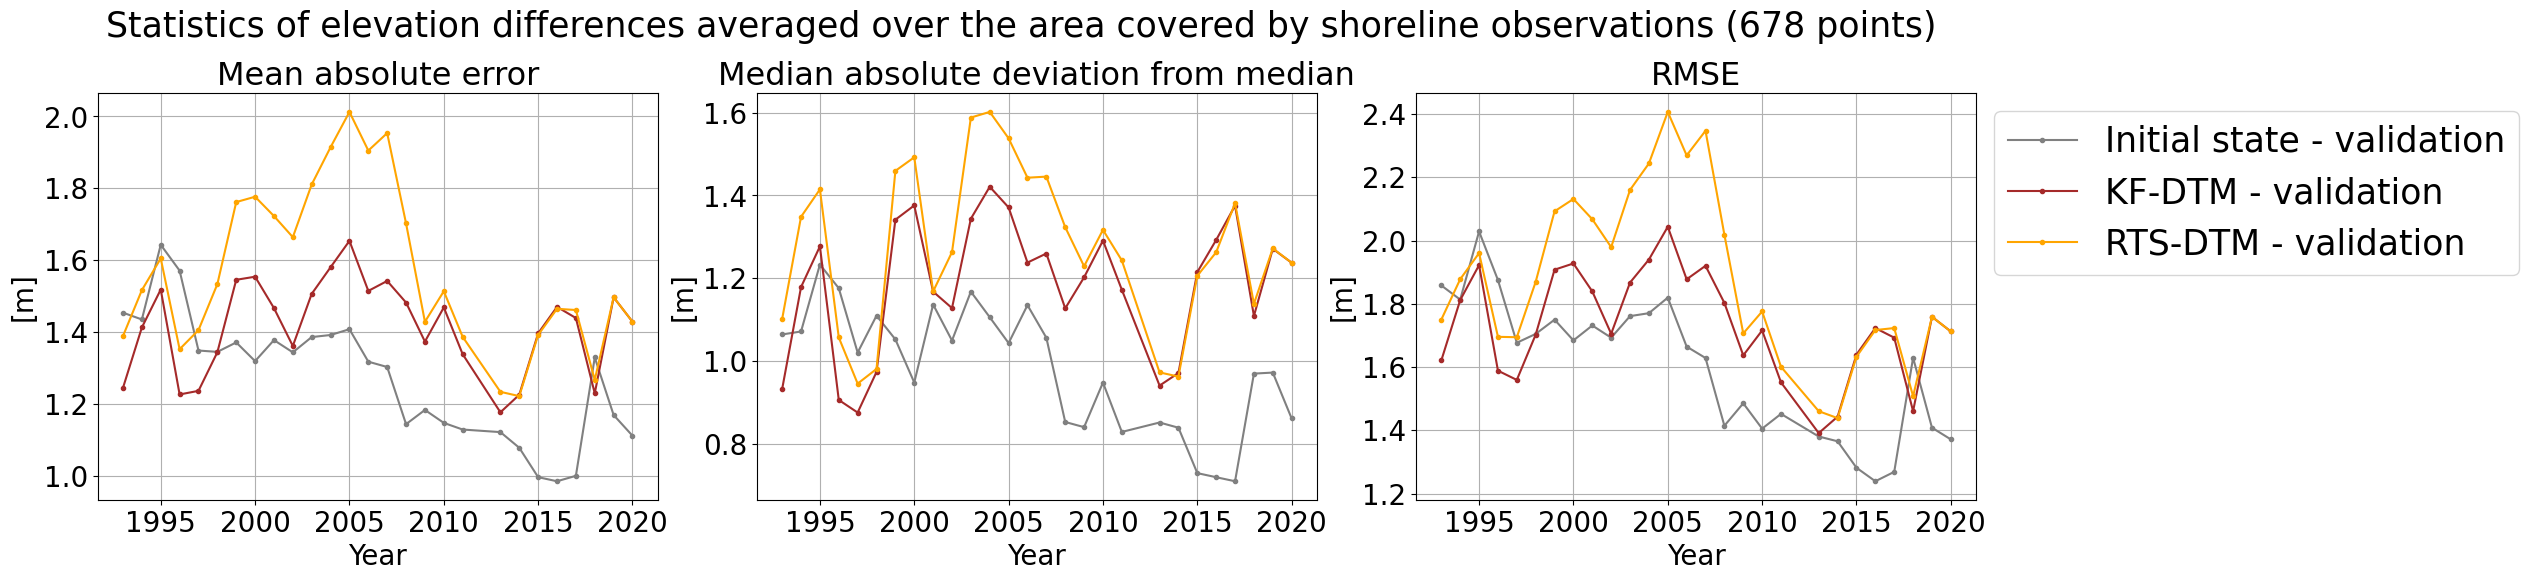

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.5)
fig.suptitle(f'Statistics of elevation differences averaged over the area covered by shoreline observations ({len(rts_inside_sl)} points)', y=1.1, fontsize=25)
plot_stats(axs[0], which_stat='mae', title='Mean absolute error', inside_sl=True)
plot_stats(axs[1], which_stat='mad_med', title='Median absolute deviation from median', inside_sl=True)
plot_stats(axs[2], which_stat='rmse', title='RMSE', legend=True, inside_sl=True)

plt.savefig(f'{path_output}Duck_vali_stats_elev-diffs_inside_shoreline_poly.png', dpi=300, bbox_inches='tight')

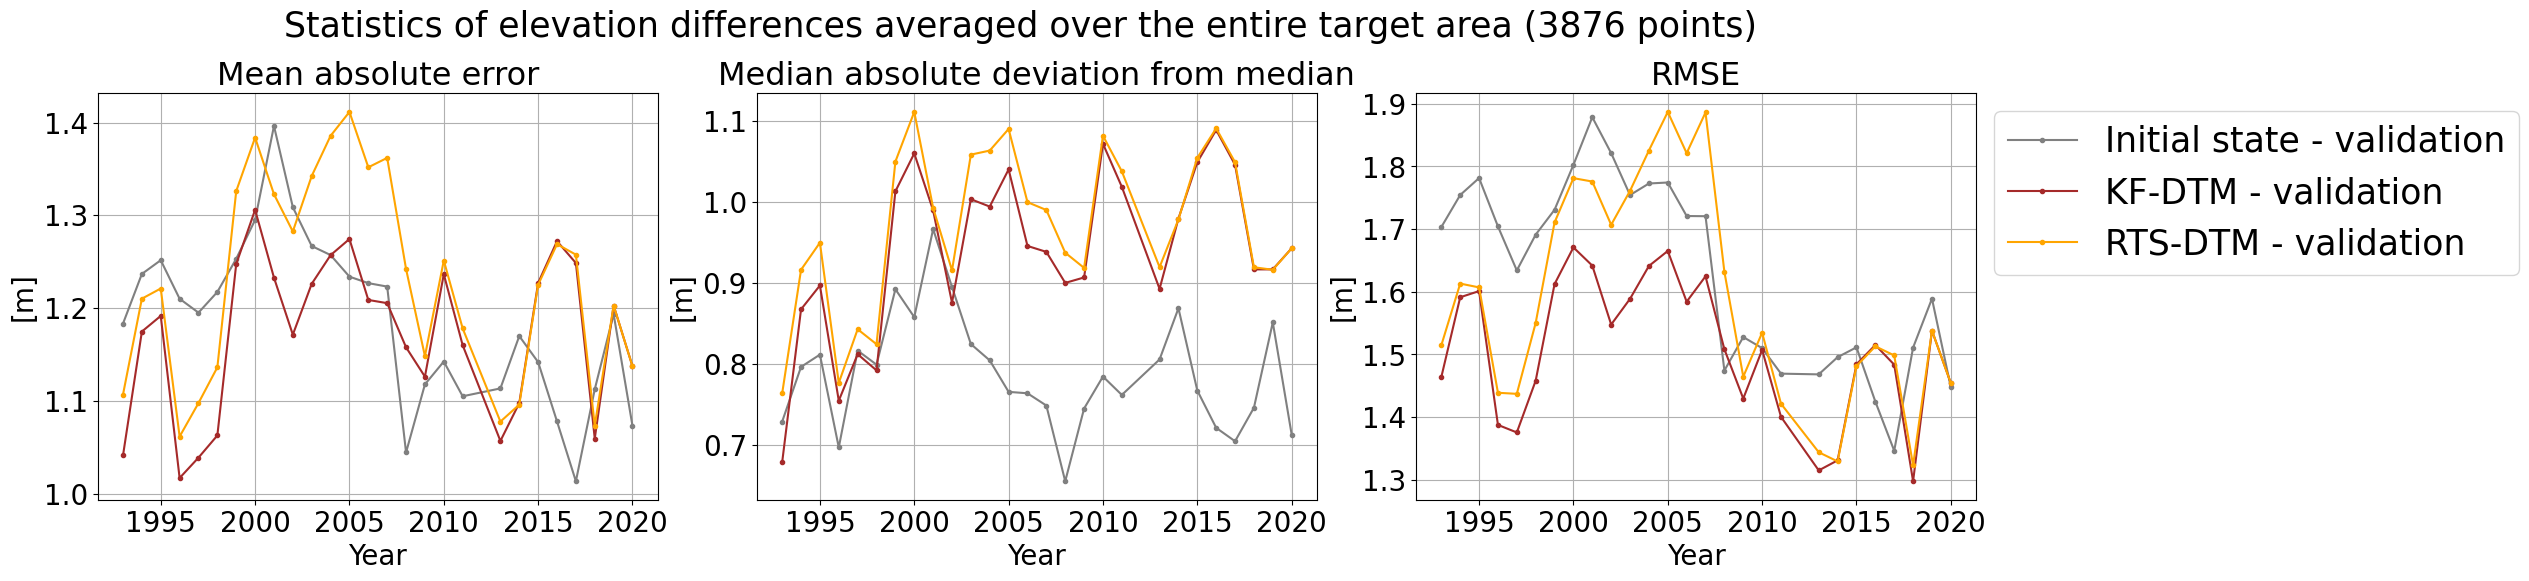

In [29]:
fig, axs = plt.subplots(1, 3, figsize=(20,5))
fig.tight_layout()
fig.subplots_adjust(hspace=.5)
fig.suptitle(f'Statistics of elevation differences averaged over the entire target area ({len(rts_interp)} points)', y=1.1, fontsize=25)
plot_stats(axs[0], which_stat='mae', title='Mean absolute error')
plot_stats(axs[1], which_stat='mad_med', title='Median absolute deviation from median')
plot_stats(axs[2], which_stat='rmse', title='RMSE', legend=True)

plt.savefig(f'{path_output}Duck_vali_stats_elev-diffs_entire_target_area.png', dpi=300, bbox_inches='tight')

## Time series of volume changes

In [30]:
volumes = pd.DataFrame(index=[int(_) for _ in vali_gdf.drop(columns='geometry').columns])

volumes['vali'] = CD_geometry.compute_volume_changes(vali_gdf, poly_target_red, col_name='', epsg_out=epsg_local)
volumes['kf'] = CD_geometry.compute_volume_changes(kf_interp, poly_target_red, col_name='', epsg_out=epsg_local)
volumes['rts'] = CD_geometry.compute_volume_changes(rts_interp, poly_target_red, col_name='', epsg_out=epsg_local)

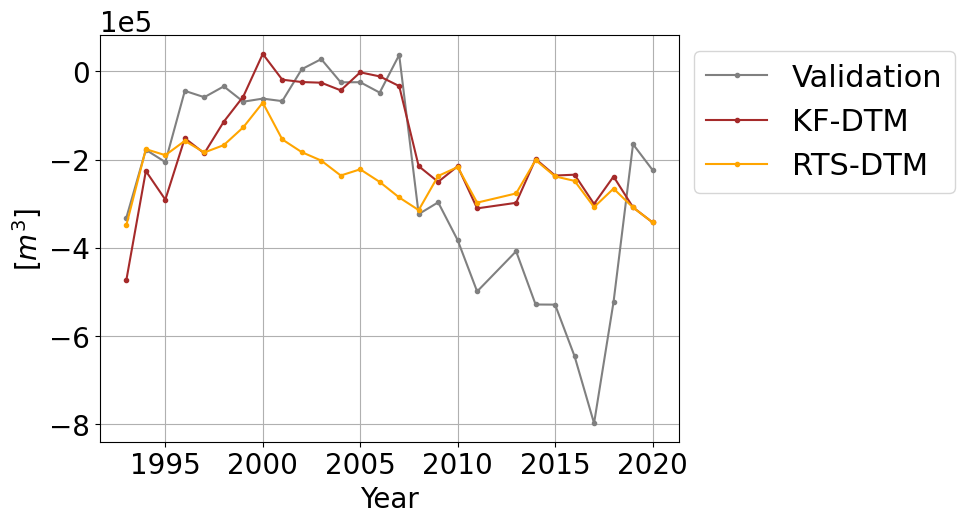

In [31]:
fig, ax = plt.subplots(figsize=(7,5))
fig.tight_layout()
fig.subplots_adjust(wspace=.25)

ax.plot(volumes.index, volumes['vali'], '.-', c=c_init, label='Validation')
ax.plot(volumes.index, volumes['kf'], '.-', c=c_kf, label='KF-DTM')
ax.plot(volumes.index, volumes['rts'], '.-', c=c_rts, label='RTS-DTM')
ax.set_ylabel(r'[$m^3$]')
ax.set_xlabel('Year')
ax.legend(bbox_to_anchor=(1,1), fontsize=22)
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax.grid()
# plt.savefig(f'{path_output}validation_volume_changes.png', dpi=300, bbox_inches='tight')

## Animation

#### KF

In [32]:
if animation:
    extent = [-75.78, -75.73, 36.16, 36.2]
    col_idx = ['x_' in _ for _ in x_state.columns]
    col_list_kf = x_state.loc[:,col_idx].columns.to_list()
    col_list_kf[1] = 'init'
    del col_list_kf[0]
    
    x_state_in_sl_poly = x_state[x_state.intersects(poly_sl_corr)]
    
    x = x_state_in_sl_poly.geometry.x
    y = x_state_in_sl_poly.geometry.y
    anim = CD_visualisation.movie(x_state_in_sl_poly, x, y,
            col_list_kf, first_col='init', extent=extent, zoom=15,
            pixelsize=10, savepath=path_output, fn='KF.gif')

#### RTS

In [33]:
if animation:
    col_idx = ['x_s' in _ for _ in x_state_s.columns]
    col_list_s = x_state_s.loc[:,col_idx].columns.to_list()
    
    x_state_s_in_sl_poly = x_state_s[x_state_s.intersects(poly_sl_corr)]
    x = x_state_s_in_sl_poly.geometry.x
    y = x_state_s_in_sl_poly.geometry.y
    
    anim_RTS = CD_visualisation.movie(x_state_s_in_sl_poly, x, y,
                col_list_s, first_col='x_s_2020', extent=extent, zoom=15,
            pixelsize=10, savepath=path_output, fn='RTS.gif')

#### Single year result map

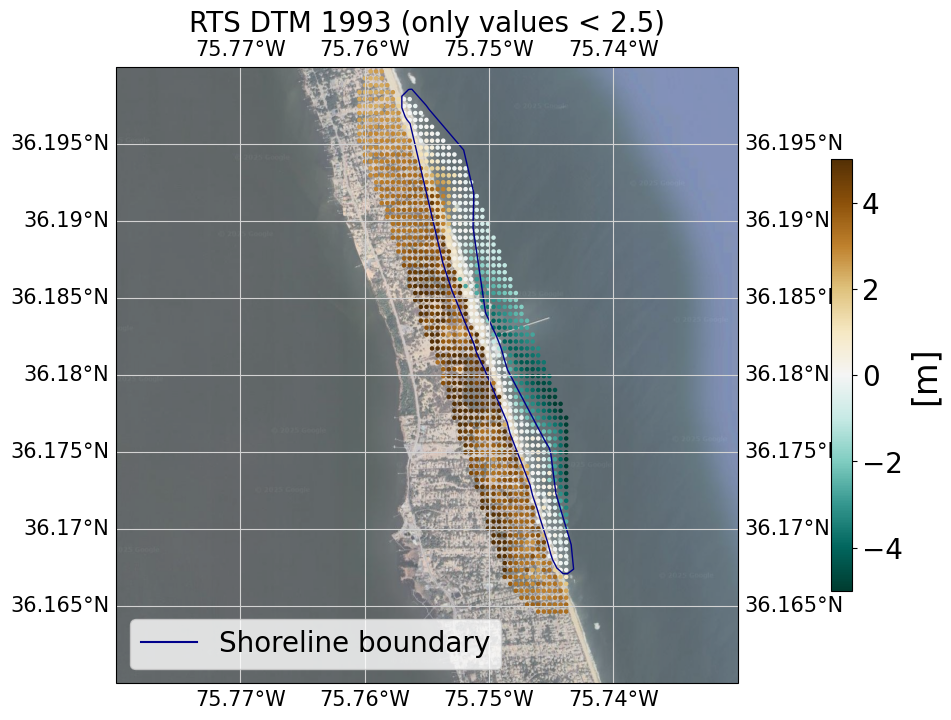

In [34]:
mask_max_elev = 2.5

extent = [-75.78, -75.73, 36.16, 36.2]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

idx, = np.where(abs(x_state_s['x_s_1993']) < mask_max_elev)
# x = x_state.geometry.x[idx]
# y = x_state.geometry.y[idx]
# data = x_state_s['x_s_1993'][idx]

x = x_state.geometry.x
y = x_state.geometry.y
data = x_state_s['x_s_1993']

plot = ax.scatter(x, y, marker='o', s=5, c = data,
                  cmap='BrBG_r', transform=ccrs.PlateCarree(), vmin=-5, vmax=5, )

ax.add_geometries(poly_sl_corr, crs=projection, facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)

plt.colorbar(plot, shrink=.7, pad=.08).set_label(label='[m]',size=24)
proxy_poly_sl_corr = Line2D([0], [0], color='darkblue', label='Shoreline boundary')
ax.legend(handles=[proxy_poly_sl_corr])
ax.set_title(f'RTS DTM 1993 (only values < {mask_max_elev})')

plt.savefig(f'{path_output}RTS_DTM_1993.png', dpi=300, bbox_inches='tight')

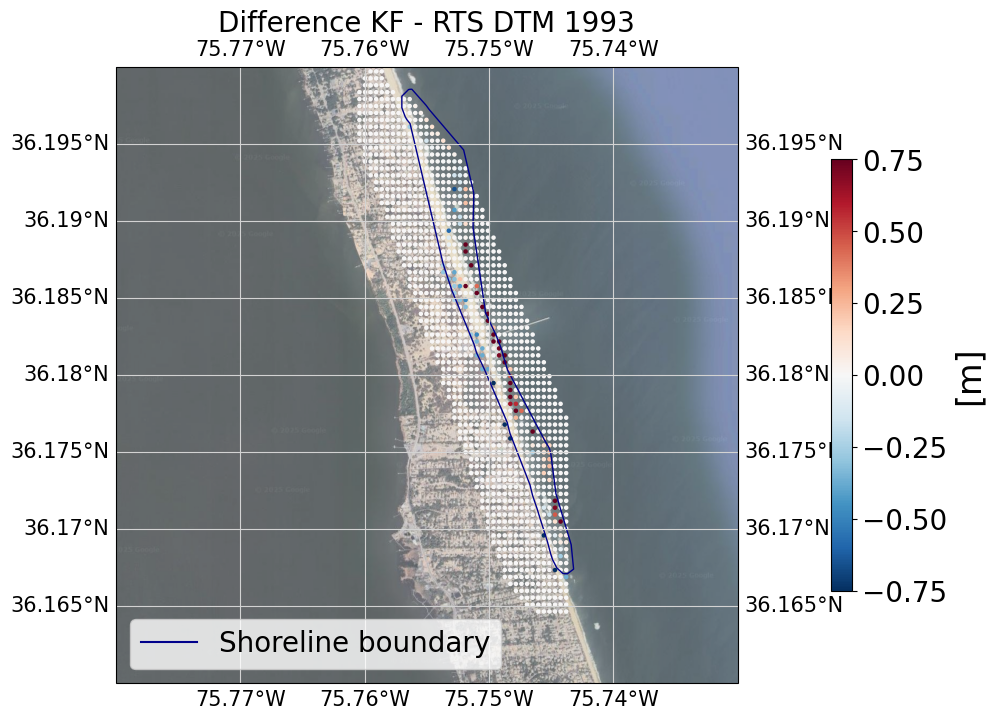

In [35]:
diff = x_state_s['x_s_1993'] - x_state['x_up_1993']

extent = [-75.78, -75.73, 36.16, 36.2]
fig, ax = CD_visualisation.plot_basemap(extent, zoom=15)

plot = ax.scatter(x_state.geometry.x, x_state.geometry.y, marker='o', s=5, c=diff,
                  cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin=-.75, vmax=.75, )

ax.add_geometries(poly_sl_corr, crs=projection, facecolor='none', edgecolor='darkblue', zorder=1, alpha=1)

plt.colorbar(plot, shrink=.7, pad=.08).set_label(label='[m]',size=24)
proxy_poly_sl_corr = Line2D([0], [0], color='darkblue', label='Shoreline boundary')
ax.legend(handles=[proxy_poly_sl_corr])
ax.set_title('Difference KF - RTS DTM 1993');

plt.savefig(f'{path_output}diff_kf-rts_1993.png', dpi=300, bbox_inches='tight')